## Importation des bibliothèques

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import DataFrame

## Ouverture des datasets

In [32]:
echon_features = pd.read_csv('echonest_features.tsv', sep='\t')
genre = pd.read_csv('genres.csv', sep=',')
spectral_features = pd.read_csv('spectral_features.tsv', sep='\t')
track_metadata = pd.read_csv('tracks.tsv', sep='\t')
merged_df = pd.concat([echon_features, spectral_features, track_metadata], ignore_index=True).groupby('track_id').first().reset_index()


merged_df.head(5)


,track_id,acousticness,danceability,energy,instrumentalness,liveness,speechiness,tempo,valence,spectral_bandwidth_kurtosis_01,...,artist_longitude,artist_name,duration,favorites,genre_top,genres,genres_all,interest,listens,title
0,11870,0.373039,0.429892,0.645929,0.769285,0.195042,0.101240,159.908,0.474554,1.386746,...,NaN,Wildahead Portibeast,131.0,0.0,Hip-Hop,[21],[21],733.0,218.0,What The Truth Should Be
1,11871,0.908215,0.427918,0.694364,0.950413,0.269082,0.180927,188.077,0.585049,0.988129,...,NaN,Wildahead Portibeast,185.0,0.0,Hip-Hop,[21],[21],753.0,267.0,It's True
2,11872,0.204111,0.501329,0.608690,0.725811,0.125451,0.623711,137.676,0.522381,-0.288111,...,NaN,Wildahead Portibeast,183.0,0.0,Hip-Hop,[21],[21],744.0,223.0,Pedestal
3,11873,0.464478,0.419687,0.743163,0.786033,0.214622,0.142762,79.371,0.644394,0.013341,...,NaN,Wildahead Portibeast,213.0,3.0,Hip-Hop,[21],[21],936.0,245.0,Timetomoveover (prod. 6th Sense)
4,11874,0.921960,0.350383,0.588584,0.861204,0.120561,0.187306,190.518,0.537996,2.176594,...,NaN,Wildahead Portibeast,162.0,0.0,Hip-Hop,[21],[21],861.0,192.0,Stranger feat. 6th Sense


## Nettoyage des données

In [33]:
print(merged_df.columns)
print(merged_df.shape)
print(echon_features.shape, spectral_features.shape, track_metadata.shape)
print(f"Le nombre de ligne unique est {merged_df['track_id'].nunique()}")

Index(['track_id', 'acousticness', 'danceability', 'energy',
       'instrumentalness', 'liveness', 'speechiness', 'tempo', 'valence',
       'spectral_bandwidth_kurtosis_01', 'spectral_bandwidth_max_01',
       'spectral_bandwidth_mean_01', 'spectral_bandwidth_median_01',
       'spectral_bandwidth_min_01', 'spectral_bandwidth_skew_01',
       'spectral_bandwidth_std_01', 'spectral_centroid_kurtosis_01',
       'spectral_centroid_max_01', 'spectral_centroid_mean_01',
       'spectral_centroid_median_01', 'spectral_centroid_min_01',
       'spectral_centroid_skew_01', 'spectral_centroid_std_01',
       'spectral_rolloff_kurtosis_01', 'spectral_rolloff_max_01',
       'spectral_rolloff_mean_01', 'spectral_rolloff_median_01',
       'spectral_rolloff_min_01', 'spectral_rolloff_skew_01',
       'spectral_rolloff_std_01', 'album_title', 'album_tracks',
       'artist_latitude', 'artist_longitude', 'artist_name', 'duration',
       'favorites', 'genre_top', 'genres', 'genres_all', 'interest

## Gestions des valeures manquantes

In [35]:
# Recheche des valeurs manquantes
missing_values = merged_df.isnull().sum()
# Affichage des pourcentages de valeurs manquantes
missing_percentage = (missing_values / len(merged_df)) * 100
# Complétion des valeurs manquantes avec la mediane de chaque colonne avec moins de 5% de valeurs manquantes
for column in merged_df.columns:
    if missing_percentage[column] > 0 and missing_percentage[column] < 5:
        if merged_df[column].dtype in [np.float64, np.int64]:
            median_value = merged_df[column].median()
            merged_df[column].fillna(median_value, inplace=True)
        else:
            merged_df[column].fillna(merged_df[column].mode()[0], inplace=True)
print(missing_percentage)

track_id                           0.000000
acousticness                      88.660019
danceability                      88.678853
energy                            88.660019
instrumentalness                  88.660019
liveness                          88.660019
speechiness                       88.808707
tempo                             88.660019
valence                           88.680835
spectral_bandwidth_kurtosis_01     0.000000
spectral_bandwidth_max_01          0.000000
spectral_bandwidth_mean_01         0.000000
spectral_bandwidth_median_01       0.000000
spectral_bandwidth_min_01          0.000000
spectral_bandwidth_skew_01         0.000000
spectral_bandwidth_std_01          0.000000
spectral_centroid_kurtosis_01      0.000000
spectral_centroid_max_01           0.000000
spectral_centroid_mean_01          0.000000
spectral_centroid_median_01        0.000000
spectral_centroid_min_01           0.000000
spectral_centroid_skew_01          0.000000
spectral_centroid_std_01        

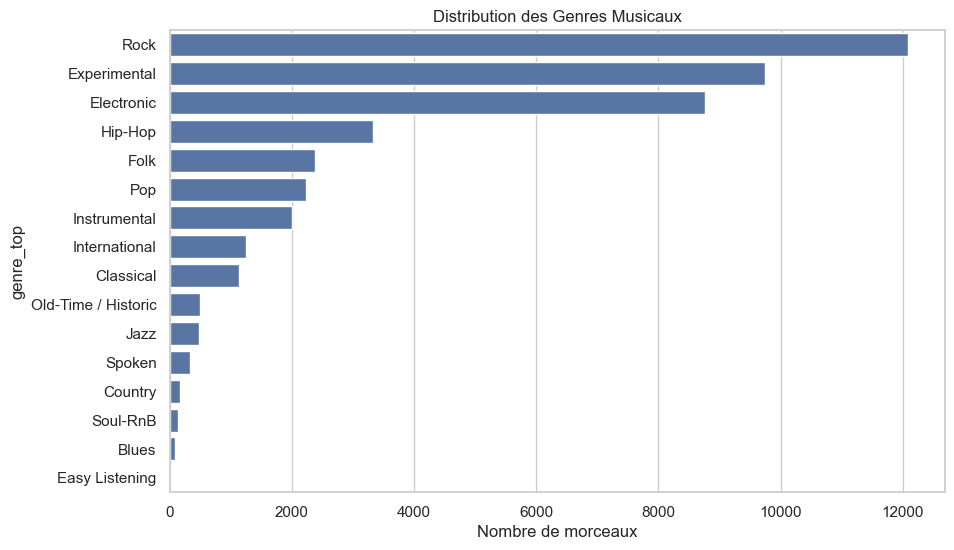

Nombre de morceaux par genre :
genre_top
Rock                   12085
Experimental            9752
Electronic              8769
Hip-Hop                 3334
Folk                    2375
Pop                     2235
Instrumental            2003
International           1256
Classical               1129
Old-Time / Historic      491
Jazz                     484
Spoken                   323
Country                  163
Soul-RnB                 131
Blues                     79
Easy Listening            24
Name: count, dtype: int64
17


In [41]:
# Filtrage des genres les plus fréquents
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
# Création du graphique en barres
sns.countplot(y='genre_top', data=track_metadata, order=track_metadata['genre_top'].value_counts().index)
plt.title("Distribution des Genres Musicaux")
plt.xlabel("Nombre de morceaux")
plt.show()

# Affichage des chiffres exacts
print("Nombre de morceaux par genre :")
print(track_metadata['genre_top'].value_counts())
print(track_metadata['genre_top'].unique().__len__())